# “Hello, world!”

In [1]:
import sys
print(sys.executable)

/home/ubuntu/anaconda3/envs/sionna/bin/python


In [2]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# IPython "magic function" for inline plots
%matplotlib inline
import matplotlib.pyplot as plt

2026-04-05 22:47:21.245173: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 22:47:21.277921: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 22:47:22.034019: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Let us first create a [BinarySource](https://nvlabs.github.io/sionna/phy/api/mapping/sionna.phy.mapping.BinarySource.html) to generate a random batch of bit vectors that we can map to constellation symbols:

In [3]:
batch_size = 1000 # Number of symbols we want to generate
num_bits_per_symbol = 4 # 16-QAM has four bits per symbol
binary_source = sionna.phy.mapping.BinarySource()
b = binary_source([batch_size, num_bits_per_symbol])
b

I0000 00:00:1775400444.432251   13332 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6163 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


<tf.Tensor: shape=(1000, 4), dtype=float32, numpy=
array([[1., 0., 0., 1.],
       [0., 1., 1., 0.],
       [0., 1., 0., 0.],
       ...,
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 1., 1.]], dtype=float32)>

Next, let us create a [Constellation](https://nvlabs.github.io/sionna/phy/api/mapping/Constellation.html) and visualize it:

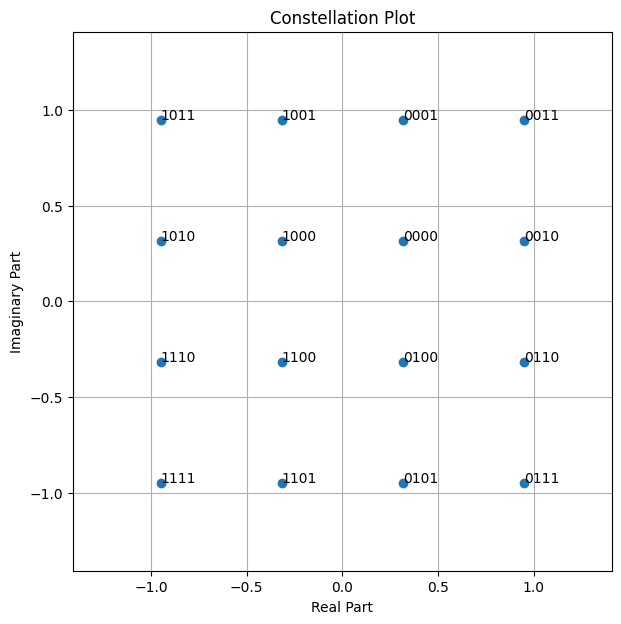

In [4]:
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
constellation.show();

We now need a [Mapper](https://nvlabs.github.io/sionna/phy/api/mapping/Mapper.html) that maps each row of b to the constellation symbols according to the bit labeling shown above.

In [5]:
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
x = mapper(b)
x[:10]

<tf.Tensor: shape=(10, 1), dtype=complex64, numpy=
array([[-0.31622776+0.94868326j],
       [ 0.94868326-0.31622776j],
       [ 0.31622776-0.31622776j],
       [ 0.94868326+0.94868326j],
       [ 0.31622776-0.94868326j],
       [ 0.31622776-0.94868326j],
       [-0.94868326-0.31622776j],
       [-0.31622776+0.31622776j],
       [ 0.94868326+0.94868326j],
       [-0.94868326+0.31622776j]], dtype=complex64)>

Let us now make things a bit more interesting a send our symbols over and [AWGN channel](https://nvlabs.github.io/sionna/phy/api/channel/wireless/awgn.html#sionna.phy.channel.AWGN):

Instructions for updating:
Use tf.identity with explicit device placement instead.


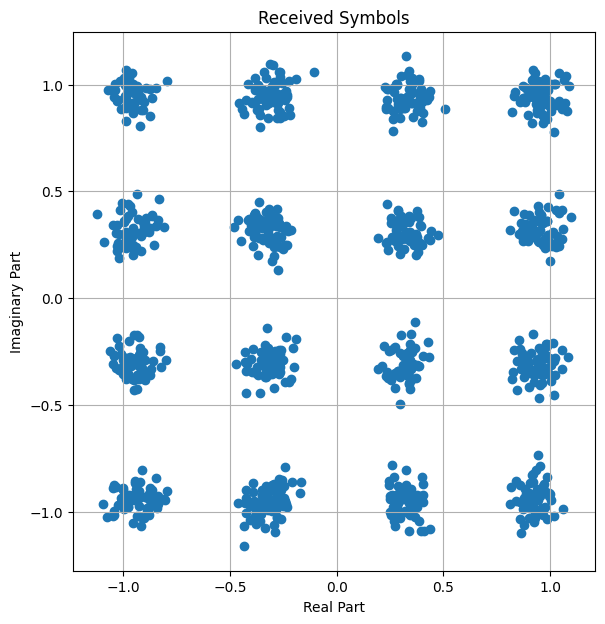

In [6]:
awgn = sionna.phy.channel.AWGN()
ebno_db = 15 # Desired Eb/No in dB
no = sionna.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol, coderate=1)
y = awgn(x, no).cpu().numpy()

# Visualize the received signal
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
plt.scatter(np.real(y), np.imag(y));
ax.set_aspect("equal", adjustable="box")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.grid(True, which="both", axis="both")
plt.title("Received Symbols");